1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("muted")

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

csv_file_path = os.path.join(path, "creditcard.csv")
print("Path:", csv_file_path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
Path: /kaggle/input/creditcardfraud/creditcard.csv


2. Load Data

In [ ]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Jumlah missing values maksimal: {df.isnull().sum().max()}")

Dimensi dataset: 284807 baris, 31 kolom
Jumlah missing values maksimal: 0


3. EDA (Exploratory Data Analysis)

Distribusi Kelas (Persentase):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


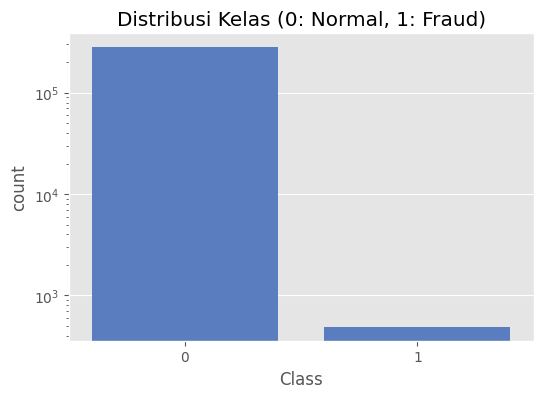

In [ ]:
print("Distribusi Kelas (Persentase):")
print(df['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribusi Kelas (0: Normal, 1: Fraud)')
plt.yscale('log') # Pakai skala log karena data sangat imbalanced
plt.show()

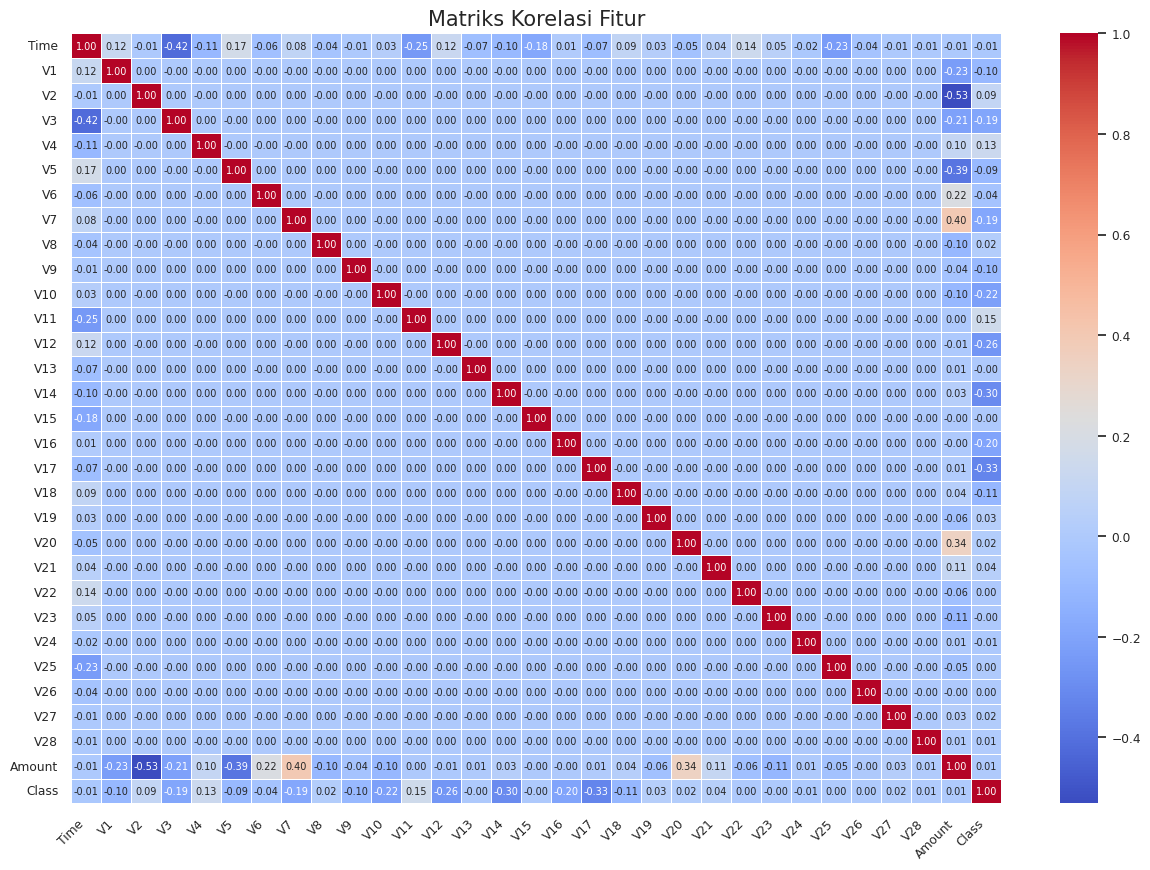

Top 5 Fitur dengan Korelasi Positif Tertinggi (Makin tinggi nilainya, makin dicurigai Fraud):
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Top 5 Fitur dengan Korelasi Negatif Tertinggi (Makin rendah nilainya, makin dicurigai Fraud):
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 10))
sns.set(font_scale=0.8, style='white')

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title('Matriks Korelasi Fitur', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

corr_with_class = corr_matrix['Class'].drop('Class')
corr_with_class_sorted = corr_with_class.sort_values(ascending=False)

print("Top 5 Fitur dengan Korelasi Positif Tertinggi (Makin tinggi nilainya, makin dicurigai Fraud):")
print(corr_with_class_sorted.head(5))
print("\nTop 5 Fitur dengan Korelasi Negatif Tertinggi (Makin rendah nilainya, makin dicurigai Fraud):")
print(corr_with_class_sorted.tail(5))

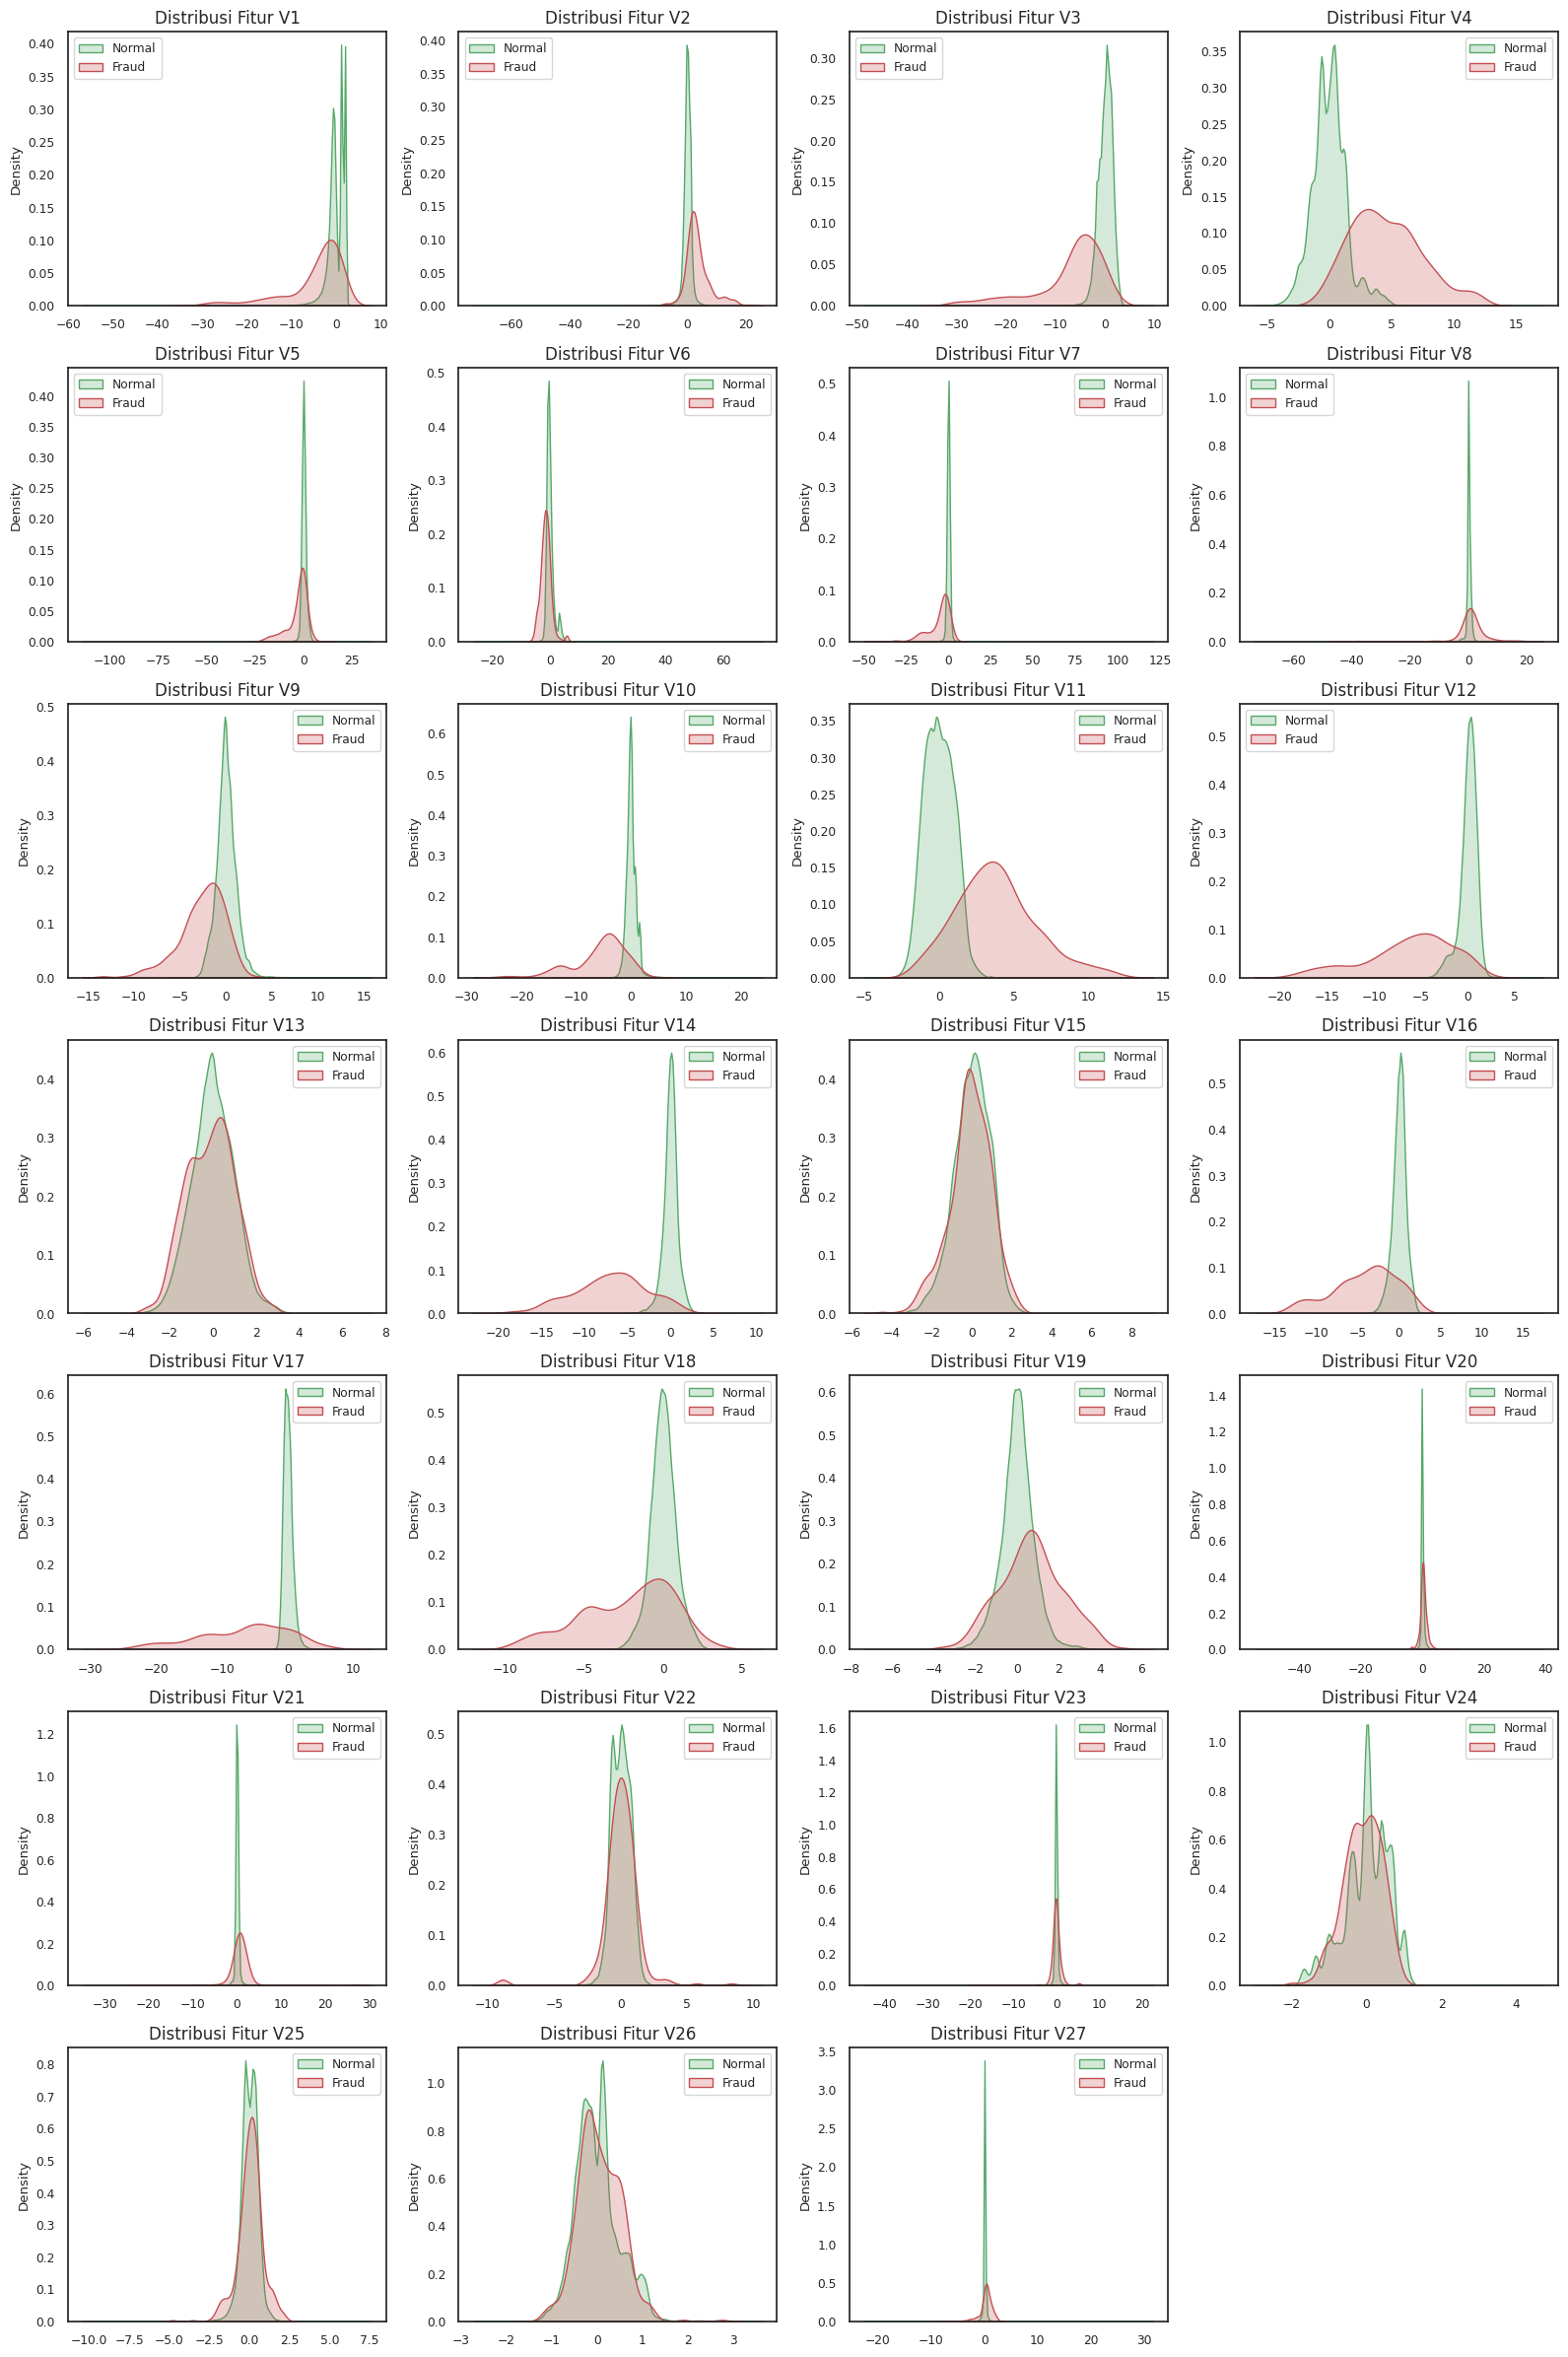

In [ ]:
import matplotlib.gridspec as gridspec

v_features = df.iloc[:, 1:28].columns

plt.figure(figsize=(16, 24))
gs = gridspec.GridSpec(7, 4)

for i, col in enumerate(v_features):
    ax = plt.subplot(gs[i])
    sns.kdeplot(df[df['Class'] == 0][col], label='Normal', fill=True, color='g', ax=ax)
    sns.kdeplot(df[df['Class'] == 1][col], label='Fraud', fill=True, color='r', ax=ax)
    ax.set_title(f'Distribusi Fitur {col}', fontsize=12)
    ax.set_xlabel('')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("Statistik Deskriptif Waktu (Time) berdasarkan Kelas:")
display(df.groupby('Class')['Time'].describe())

mean_normal = df[df['Class'] == 0]['Time'].mean()
mean_fraud = df[df['Class'] == 1]['Time'].mean()

print(f"\nRata-rata waktu transaksi normal: {mean_normal:.2f} detik")
print(f"Rata-rata waktu transaksi fraud: {mean_fraud:.2f} detik")
print(f"Selisih rata-rata: {abs(mean_normal - mean_fraud):.2f} detik")

Statistik Deskriptif Waktu (Time) berdasarkan Kelas:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0



Rata-rata waktu transaksi normal: 94838.20 detik
Rata-rata waktu transaksi fraud: 80746.81 detik
Selisih rata-rata: 14091.40 detik


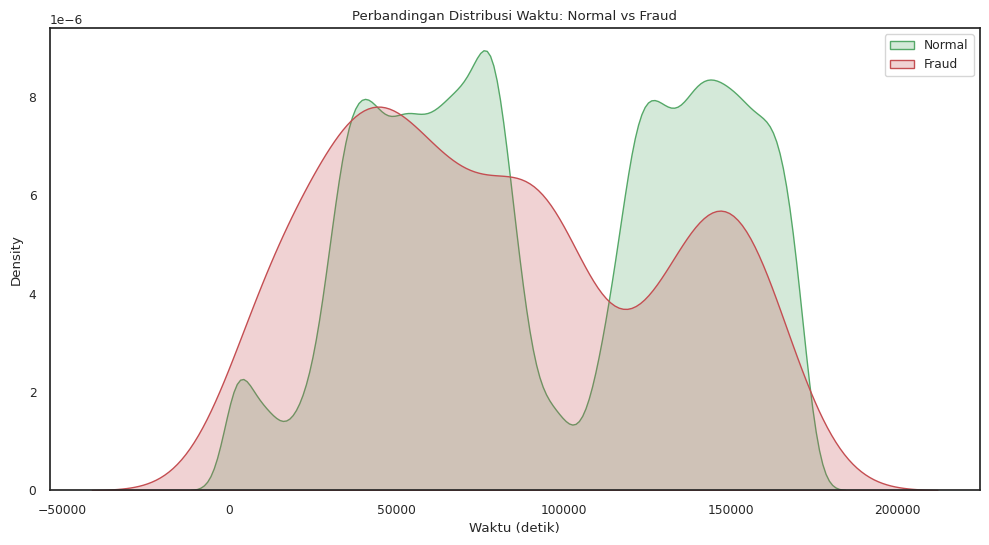

In [ ]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal', fill=True, color='g')
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud', fill=True, color='r')
plt.title('Perbandingan Distribusi Waktu: Normal vs Fraud')
plt.xlabel('Waktu (detik)')
plt.ylabel('Density')
plt.legend()
plt.show()

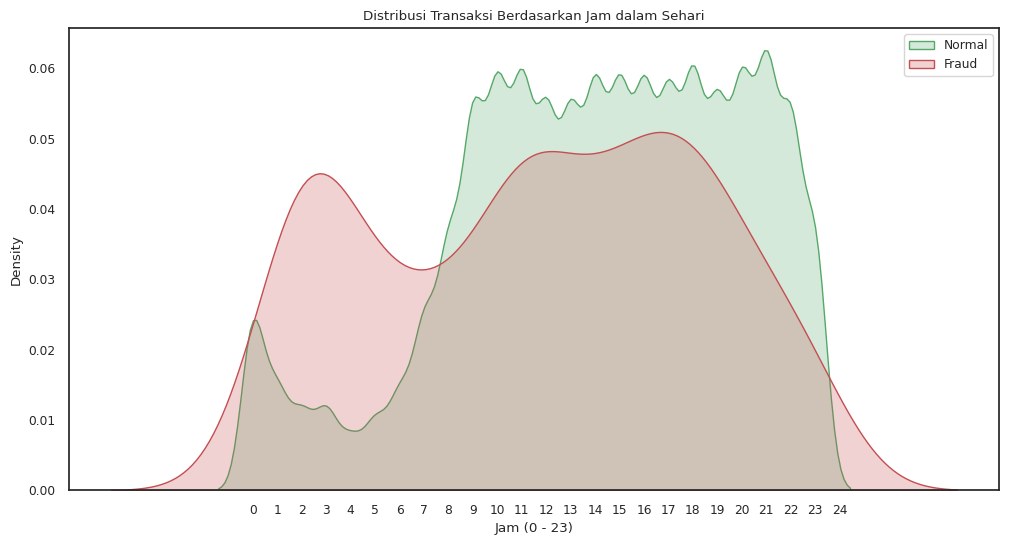

Rata-rata jam transaksi Fraud: 11.646341463414634
Rata-rata jam transaksi Normal: 14.050623428239804


In [ ]:
temp_hour = (df['Time'] // 3600) % 24

plt.figure(figsize=(12, 6))
sns.kdeplot(temp_hour[df['Class'] == 0], label='Normal', fill=True, color='g')
sns.kdeplot(temp_hour[df['Class'] == 1], label='Fraud', fill=True, color='r')

plt.title('Distribusi Transaksi Berdasarkan Jam dalam Sehari')
plt.xlabel('Jam (0 - 23)')
plt.ylabel('Density')
plt.xticks(range(0, 25))
plt.legend()
plt.show()

print("Rata-rata jam transaksi Fraud:", temp_hour[df['Class'] == 1].mean())
print("Rata-rata jam transaksi Normal:", temp_hour[df['Class'] == 0].mean())

Statistik Deskriptif Amount berdasarkan Kelas:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


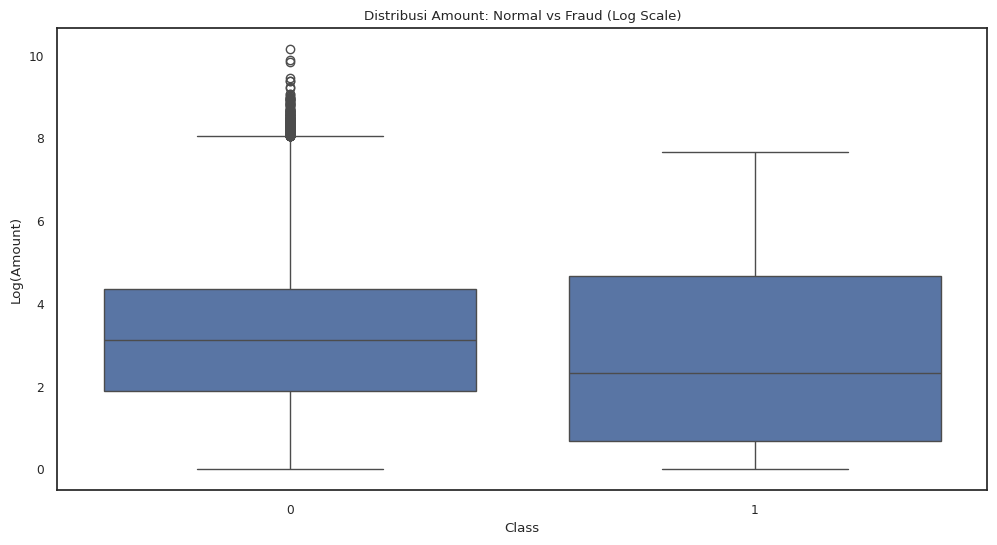

In [ ]:
print("Statistik Deskriptif Amount berdasarkan Kelas:")
display(df.groupby('Class')['Amount'].describe())

plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y=np.log1p(df['Amount']), data=df)
plt.title('Distribusi Amount: Normal vs Fraud (Log Scale)')
plt.ylabel('Log(Amount)')
plt.show()

4. Perbandingan Standard vs Robust Scaler

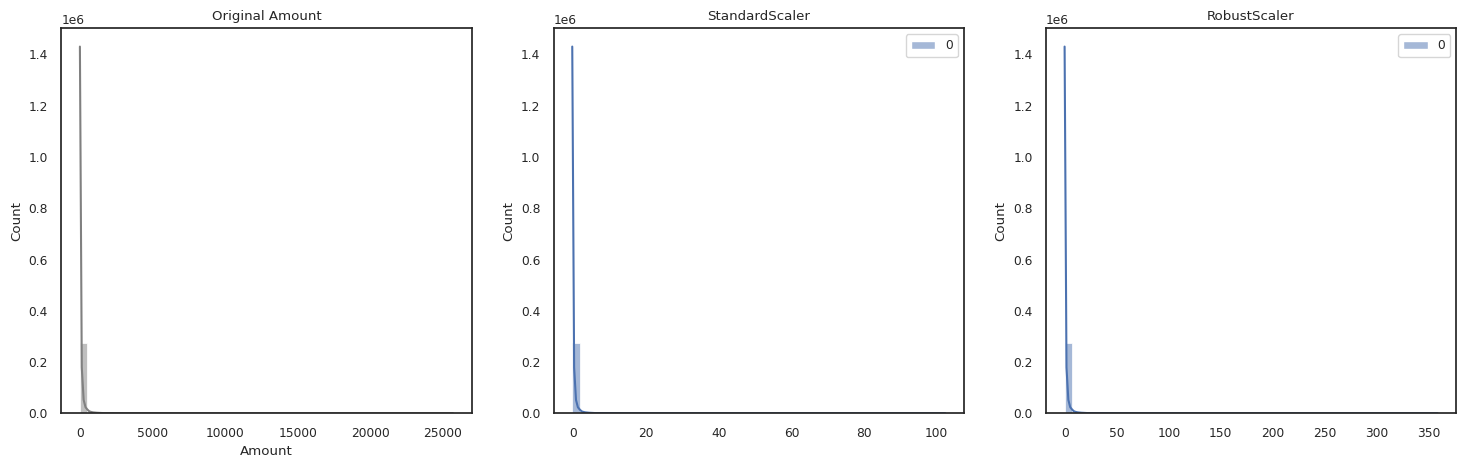

Kesimpulan: RobustScaler menangani pencilan (outlier) pada 'Amount' jauh lebih baik dibandingkan StandardScaler karena menggunakan nilai median dan quartile.


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Original
sns.histplot(df['Amount'], bins=50, ax=ax[0], color='gray', kde=True)
ax[0].set_title('Original Amount')

# StandardScaler
std_scaler = StandardScaler()
std_amount = std_scaler.fit_transform(df[['Amount']])
sns.histplot(std_amount, bins=50, ax=ax[1], color='blue', kde=True)
ax[1].set_title('StandardScaler')

# RobustScaler
rob_scaler = RobustScaler()
rob_amount = rob_scaler.fit_transform(df[['Amount']])
sns.histplot(rob_amount, bins=50, ax=ax[2], color='red', kde=True)
ax[2].set_title('RobustScaler')

plt.show()
print("Kesimpulan: RobustScaler menangani pencilan (outlier) pada 'Amount' jauh lebih baik dibandingkan StandardScaler karena menggunakan nilai median dan quartile.")

5. Split Train dan Test

In [ ]:
X = df.drop(['Class'], axis=1)
y = df['Class']

# Split data (80% Train, 20% Test) dengan stratify agar rasio fraud terjaga
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Train: {X_train.shape[0]}")
print(f"Jumlah Data Test: {X_test.shape[0]}")

Jumlah Data Train: 227845
Jumlah Data Test: 56962


6. Memakai Robust Scaler dan Drop Fitur

In [ ]:
scaler = RobustScaler()

X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

# Drop fitur yang distribusinya mirip
features_to_drop = ['V13', 'V15', 'V22', 'V24', 'V25', 'V26']
X_train = X_train.drop(features_to_drop, axis=1)
X_test = X_test.drop(features_to_drop, axis=1)

7. Undersampling Data Train

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Distribusi Kelas Train (Undersampling):")
print(y_train_under.value_counts())

Distribusi Kelas Train (Undersampling):
Class
0    394
1    394
Name: count, dtype: int64


8. Oversampling Data Train (SMOTE)

In [ ]:
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("Distribusi Kelas Train (Oversampling SMOTE):")
print(y_train_over.value_counts())

Distribusi Kelas Train (Oversampling SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


9. Cost Sensitive

In [ ]:
svm_cost_weights = 'balanced'
xgb_scale_pos_weight = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

print(f"Rasio XGBoost Pos Weight: {xgb_scale_pos_weight:.2f}")

Rasio XGBoost Pos Weight: 577.29


10. Fair Ensemble Data Train

In [ ]:
# Membagi data normal menjadi beberapa bin kecil yang seimbang dengan data fraud
fraud_idx = y_train[y_train == 1].index
normal_idx = y_train[y_train == 0].index

n_fraud = len(fraud_idx)
n_normal = len(normal_idx)

n_models = int(n_normal / n_fraud)
ensemble_data = []

np.random.seed(42)
shuffled_normal_idx = np.random.permutation(normal_idx)

for i in range(n_models):
    start = i * n_fraud
    end = (i + 1) * n_fraud
    chunk_normal = shuffled_normal_idx[start:end]

    # Gabungkan bin normal dengan semua data fraud
    combined_idx = np.concatenate([chunk_normal, fraud_idx])

    X_subset = X_train.loc[combined_idx]
    y_subset = y_train.loc[combined_idx]
    ensemble_data.append((X_subset, y_subset))

print(f"Rasio Normal/Fraud: {n_normal/n_fraud:.2f}")
print(f"Berhasil membuat {n_models} subset training untuk Fair Ensemble.")

Rasio Normal/Fraud: 577.29
Berhasil membuat 577 subset training untuk Fair Ensemble.


11. Model SVM Memakai Undersampling dan Evaluasi

In [ ]:
svm_under = LinearSVC(max_iter=5000, random_state=42, dual=False)
svm_under.fit(X_train_under, y_train_under)
y_pred_svm_under = svm_under.predict(X_test)

print("=== SVM (Undersampling) ===")
print(classification_report(y_test, y_pred_svm_under))
print("AUPRC:", average_precision_score(y_test, svm_under.decision_function(X_test)))

=== SVM (Undersampling) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962

AUPRC: 0.6846950395350483


12. Model SVM Memakai Oversampling dan Evaluasi

In [ ]:
svm_over = LinearSVC(max_iter=5000, random_state=42, dual=False)
svm_over.fit(X_train_over, y_train_over)
y_pred_svm_over = svm_over.predict(X_test)

print("=== SVM (Oversampling) ===")
print(classification_report(y_test, y_pred_svm_over))
print("AUPRC:", average_precision_score(y_test, svm_over.decision_function(X_test)))

=== SVM (Oversampling) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.09      0.91      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.95      0.58     56962
weighted avg       1.00      0.98      0.99     56962

AUPRC: 0.7085867824823022


13. Model SVM Memakai Cost Sensitive dan Evaluasi

In [ ]:
svm_cost = LinearSVC(class_weight=svm_cost_weights, max_iter=5000, random_state=42, dual=False)
svm_cost.fit(X_train, y_train) # Menggunakan data train asli
y_pred_svm_cost = svm_cost.predict(X_test)

print("=== SVM (Cost Sensitive) ===")
print(classification_report(y_test, y_pred_svm_cost))
print("AUPRC:", average_precision_score(y_test, svm_cost.decision_function(X_test)))

=== SVM (Cost Sensitive) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.92      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.56     56962
weighted avg       1.00      0.98      0.99     56962

AUPRC: 0.7181631196068321


14. Model SVM Memakai Fair Ensemble dan Evaluasi

In [ ]:
svm_models = []
for X_sub, y_sub in ensemble_data:
    model = LinearSVC(max_iter=5000, random_state=42, dual=False)
    model.fit(X_sub, y_sub)
    svm_models.append(model)

# Voting dan Evaluasi
svm_all_preds = np.array([m.predict(X_test) for m in svm_models])
y_pred_svm_ens = (np.mean(svm_all_preds, axis=0) > 0.5).astype(int)
svm_ens_scores = np.mean([m.decision_function(X_test) for m in svm_models], axis=0)

print("=== SVM (Fair Ensemble) ===")
print(classification_report(y_test, y_pred_svm_ens))
print("AUPRC:", average_precision_score(y_test, svm_ens_scores))

=== SVM (Fair Ensemble) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.98     56962

AUPRC: 0.6508170736890191


15. Kesimpulan Mencoba Ganti Model ke XGBoost

**Kesimpulan SVM:**
Berdasarkan metrik klasifikasi (terutama *Precision*, *Recall*, dan *AUPRC*), model Linear SVM cenderung mengalami kesulitan. Jika kita memakai *Undersampling*, *Recall* mungkin tinggi, namun *Precision* akan hancur lebur (banyak *False Positives*/salah tebak transaksi normal sebagai penipuan). Sedangkan *SMOTE* dapat memakan komputasi yang sangat lambat.

**Solusi: XGBoost**
XGBoost adalah algoritma *tree-based ensemble* yang sangat andal pada data berstruktur tabular dan mampu menangani ketidakseimbangan kelas (*imbalanced data*) secara *native* menggunakan parameter metrik internal. Oleh karena itu, kita akan beralih menggunakan XGBoost dengan penyesuaian bobot (*Cost-Sensitive*).

16. Model XGBoost dengan Cost Sensitive dan Evaluasi

In [ ]:
xgb_cost = XGBClassifier(scale_pos_weight=xgb_scale_pos_weight, random_state=42, eval_metric='logloss')
xgb_cost.fit(X_train, y_train)

y_pred_xgb_cost = xgb_cost.predict(X_test)
y_prob_xgb_cost = xgb_cost.predict_proba(X_test)[:, 1]

print("=== XGBoost (Cost Sensitive) ===")
print(classification_report(y_test, y_pred_xgb_cost))
print("AUPRC:", average_precision_score(y_test, y_prob_xgb_cost))

=== XGBoost (Cost Sensitive) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.86      0.88        98

    accuracy                           1.00     56962
   macro avg       0.96      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC: 0.8764831252107784


17. Model XGBoost memakai Undersampling dan evaluasi

In [ ]:
xgb_under = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_under.fit(X_train_under, y_train_under)

y_pred_xgb_under = xgb_under.predict(X_test)
y_prob_xgb_under = xgb_under.predict_proba(X_test)[:, 1]

print("=== XGBoost (Undersampling) ===")
print(classification_report(y_test, y_pred_xgb_under))
print("AUPRC:", average_precision_score(y_test, y_prob_xgb_under))

=== XGBoost (Undersampling) ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.03      0.93      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.95      0.97     56962

AUPRC: 0.5908971281251654


18. Model XGBoost memakai Oversampling dan evaluasi

In [ ]:
xgb_over = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_over.fit(X_train_over, y_train_over)

y_pred_xgb_over = xgb_over.predict(X_test)
y_prob_xgb_over = xgb_over.predict_proba(X_test)[:, 1]

print("=== XGBoost (Oversampling SMOTE) ===")
print(classification_report(y_test, y_pred_xgb_over))
print("AUPRC:", average_precision_score(y_test, y_prob_xgb_over))

=== XGBoost (Oversampling SMOTE) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC: 0.876151885719183


19. Model XGBoost memakai Fair Ensemble dan evaluasi

In [ ]:
xgb_models = []
for X_sub, y_sub in ensemble_data:
    # Train XGBoost untuk masing-masing subset
    model = XGBClassifier(random_state=42, eval_metric='logloss')
    model.fit(X_sub, y_sub)
    xgb_models.append(model)

# Menggabungkan prediksi (Average of probabilities)
xgb_all_probs = np.array([m.predict_proba(X_test)[:, 1] for m in xgb_models])
y_prob_xgb_ens = np.mean(xgb_all_probs, axis=0)
y_pred_xgb_ens = (y_prob_xgb_ens > 0.5).astype(int)

print("=== XGBoost (Fair Ensemble) ===")
print(classification_report(y_test, y_pred_xgb_ens))
print("AUPRC:", average_precision_score(y_test, y_prob_xgb_ens))

=== XGBoost (Fair Ensemble) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.92      0.09        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962

AUPRC: 0.8504933514262089


20. Visualisasi Perbandingan Model (Grouped Barplot)

Tabel Perbandingan Skor:


,Model,Precision,Recall,F1-Score,AUPRC
0,SVM Under,0.067991,0.908163,0.126510,0.684695
1,SVM Over,0.092805,0.908163,0.168401,0.708587
2,SVM Cost,0.072000,0.918367,0.133531,0.718163
3,SVM Ens,0.055211,0.908163,0.104094,0.650817
4,XGB Cost,0.913043,0.857143,0.884211,0.876483
5,XGB Under,0.032247,0.928571,0.062329,0.590897
6,XGB Over,0.800000,0.857143,0.827586,0.876152
7,XGB Ens,0.045068,0.918367,0.085919,0.850493


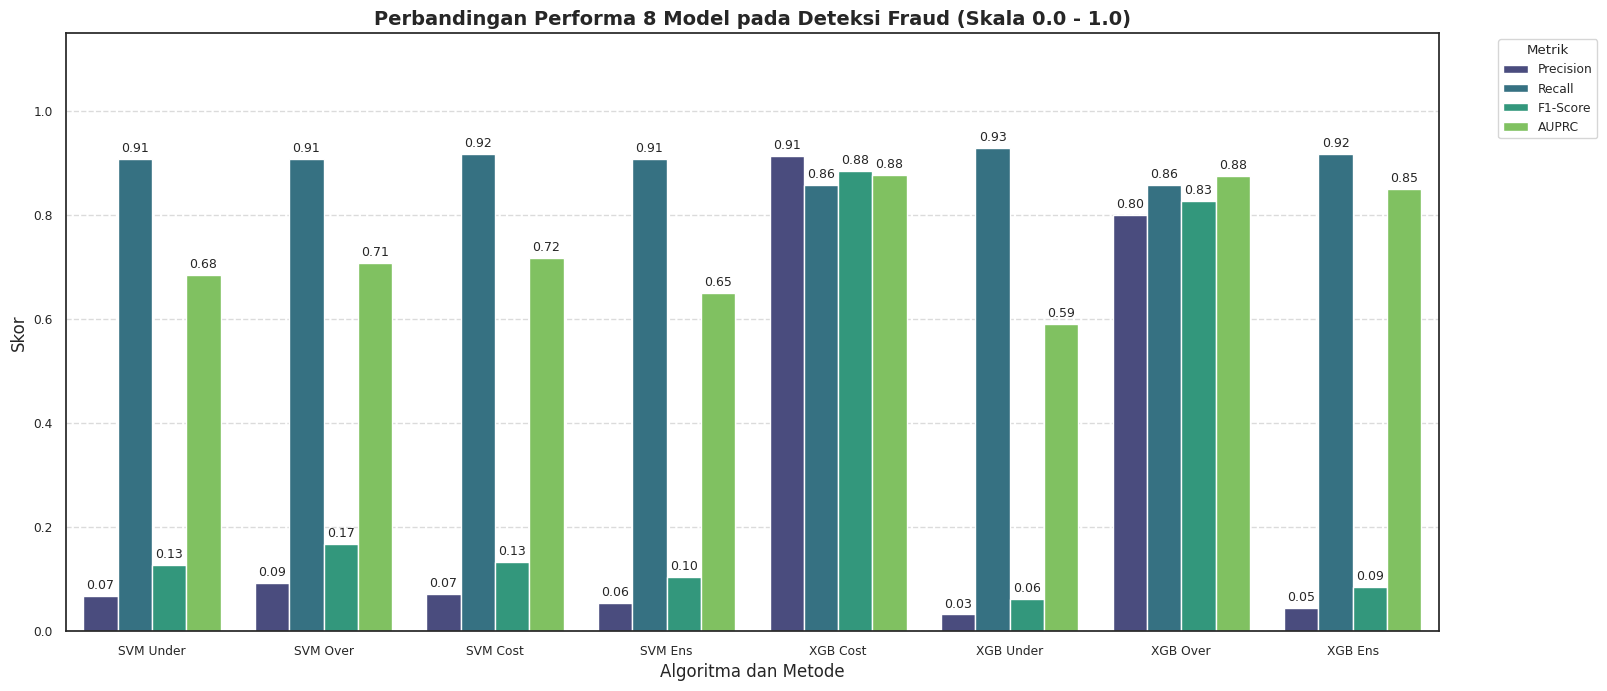

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Mengumpulkan semua prediksi dari 8 model
models_info = [
    ("SVM Under", y_pred_svm_under, svm_under.decision_function(X_test)),
    ("SVM Over", y_pred_svm_over, svm_over.decision_function(X_test)),
    ("SVM Cost", y_pred_svm_cost, svm_cost.decision_function(X_test)),
    ("SVM Ens", y_pred_svm_ens, svm_ens_scores),
    ("XGB Cost", y_pred_xgb_cost, y_prob_xgb_cost),
    ("XGB Under", y_pred_xgb_under, y_prob_xgb_under),
    ("XGB Over", y_pred_xgb_over, y_prob_xgb_over),
    ("XGB Ens", y_pred_xgb_ens, y_prob_xgb_ens)
]

# Menghitung metrik untuk kelas 1 (Fraud)
metrics_list = []
for name, y_pred, y_prob in models_info:
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_prob)
    metrics_list.append([name, prec, rec, f1, auprc])

df_metrics = pd.DataFrame(metrics_list, columns=['Model', 'Precision', 'Recall', 'F1-Score', 'AUPRC'])
print("Tabel Perbandingan Skor:")
display(df_metrics)

df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(16, 7))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.title('Perbandingan Performa 8 Model pada Deteksi Fraud (Skala 0.0 - 1.0)', fontsize=14, fontweight='bold')
plt.xlabel('Algoritma dan Metode', fontsize=12)
plt.ylabel('Skor', fontsize=12)
plt.ylim(0, 1.15)
plt.legend(loc='upper right', title='Metrik', bbox_to_anchor=(1.12, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


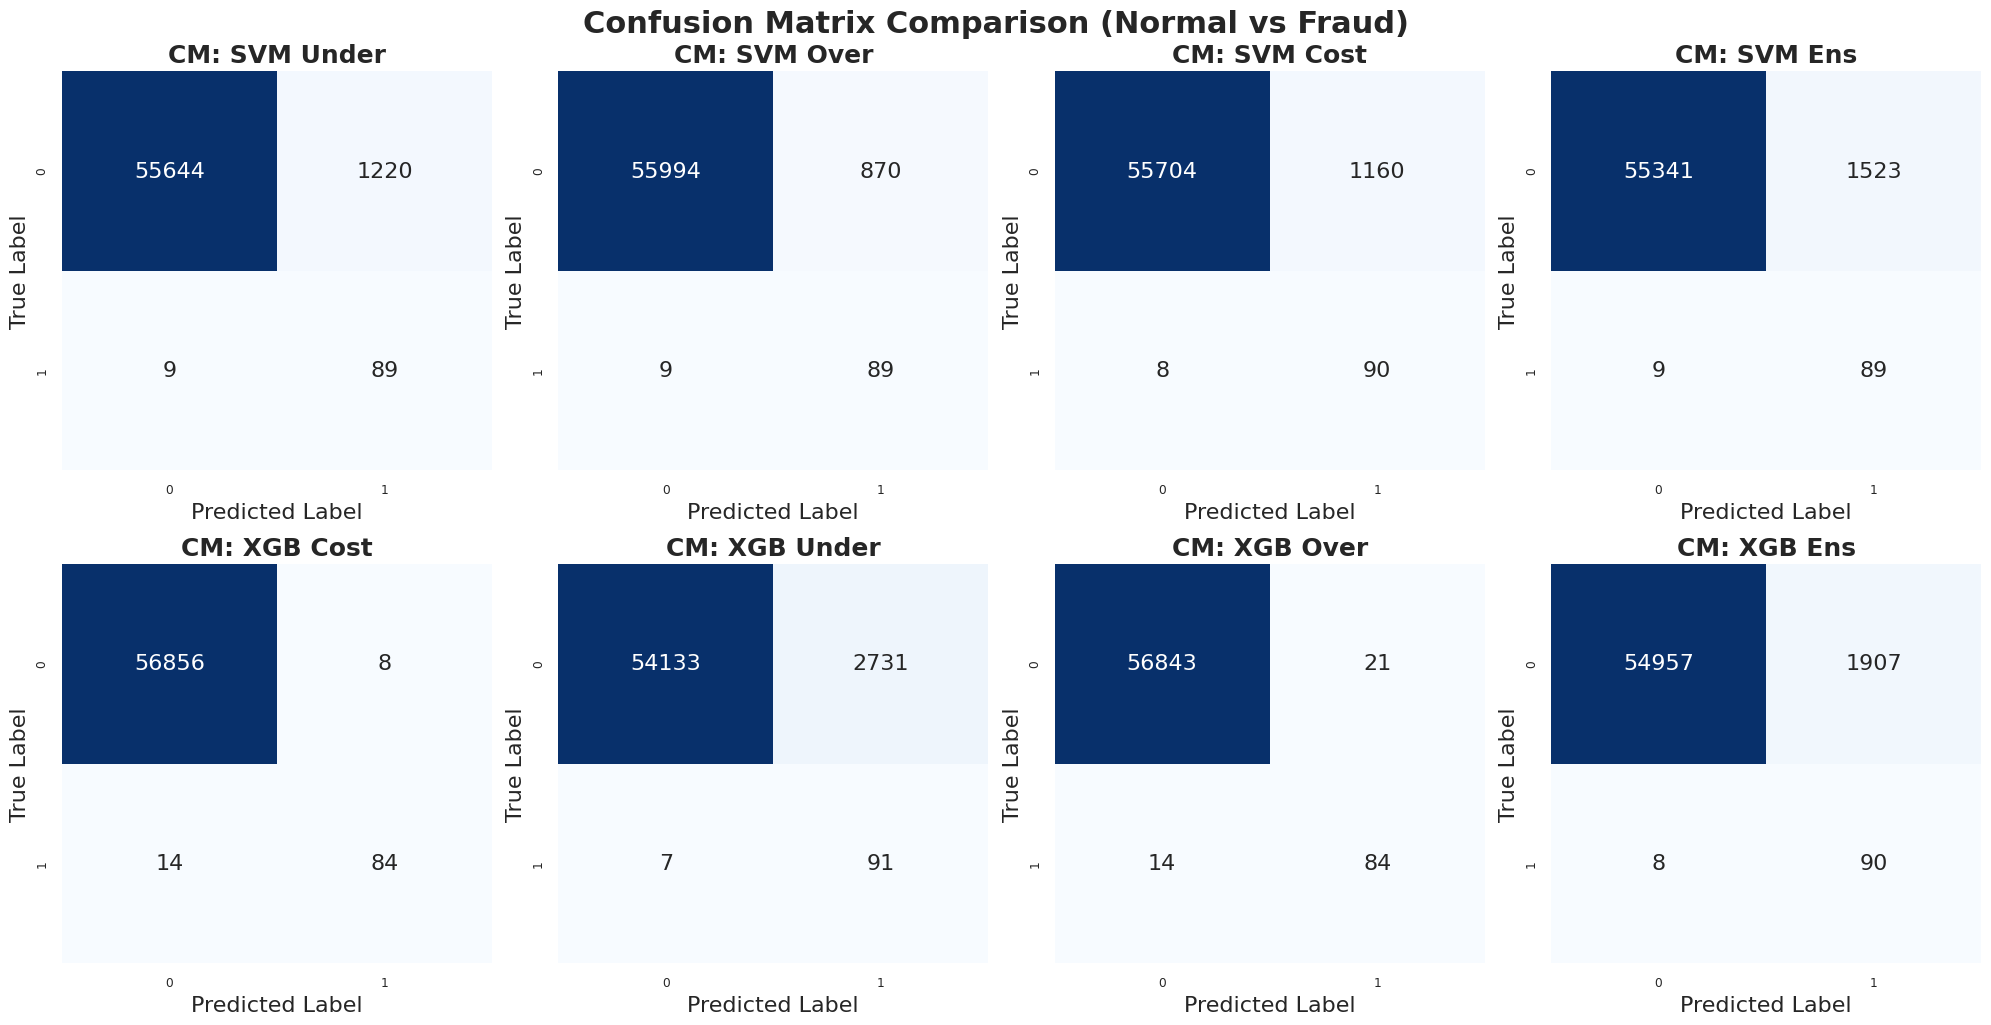

In [ ]:
from sklearn.metrics import confusion_matrix
import math

models_info = [m for m in models_info if "Optuna" not in m[0]]
model_names = [name for name, _, _ in models_info]
model_preds = [y_pred for _, y_pred, _ in models_info]

n_total_models = len(models_info)
n_cols = 4
n_rows = math.ceil(n_total_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(zip(model_names, model_preds)):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 16})
    axes[i].set_title(f'CM: {name}', fontsize=18, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=16)
    axes[i].set_ylabel('True Label', fontsize=16)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Confusion Matrix Comparison (Normal vs Fraud)', fontsize=22, fontweight='bold', y=1.02)
plt.show()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.5 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import f1_score

# 1. Optuna Linear SVM
def svm_objective(trial):
    c_val = trial.suggest_float('C', 1e-4, 10, log=True)
    model = LinearSVC(C=c_val, class_weight='balanced', max_iter=5000, random_state=42, dual=False)
    model.fit(X_train, y_train)
    # Menggunakan predict untuk mendapatkan label kelas untuk menghitung F1-Score
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

print("Optimizing SVM based on F1-Score...")
svm_study = optuna.create_study(direction='maximize')
svm_study.optimize(svm_objective, n_trials=10)

# 2. Optuna XGBoost
def xgb_objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': xgb_scale_pos_weight,
        'eval_metric': 'logloss',
        'random_state': 42
    }
    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

print("Optimizing XGBoost based on F1-Score...")
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=100)

[I 2026-06-06 07:32:44,665] A new study created in memory with name: no-name-c0caf2ab-0185-41c4-a774-a811f90c2647


Optimizing SVM based on F1-Score...


[I 2026-06-06 07:32:50,940] Trial 0 finished with value: 0.13313609467455623 and parameters: {'C': 0.015778463625201865}. Best is trial 0 with value: 0.13313609467455623.
[I 2026-06-06 07:32:59,037] Trial 1 finished with value: 0.13412816691505217 and parameters: {'C': 0.0016068400912308196}. Best is trial 1 with value: 0.13412816691505217.
[I 2026-06-06 07:33:06,209] Trial 2 finished with value: 0.13303769401330376 and parameters: {'C': 1.5368344385932347}. Best is trial 1 with value: 0.13412816691505217.
[I 2026-06-06 07:33:15,467] Trial 3 finished with value: 0.13313609467455623 and parameters: {'C': 0.005727808505201263}. Best is trial 1 with value: 0.13412816691505217.
[I 2026-06-06 07:33:20,188] Trial 4 finished with value: 0.13303769401330376 and parameters: {'C': 0.01741153885512901}. Best is trial 1 with value: 0.13412816691505217.
[I 2026-06-06 07:33:24,503] Trial 5 finished with value: 0.133630289532294 and parameters: {'C': 0.007888542054439257}. Best is trial 1 with value:

Optimizing XGBoost based on F1-Score...


[I 2026-06-06 07:33:46,157] Trial 0 finished with value: 0.5386996904024768 and parameters: {'n_estimators': 124, 'max_depth': 4, 'learning_rate': 0.09169203038285145, 'subsample': 0.8762339861910837, 'colsample_bytree': 0.9840088178453699}. Best is trial 0 with value: 0.5386996904024768.
[I 2026-06-06 07:33:53,135] Trial 1 finished with value: 0.865979381443299 and parameters: {'n_estimators': 129, 'max_depth': 9, 'learning_rate': 0.2048667201033218, 'subsample': 0.9836078719419685, 'colsample_bytree': 0.9643570319034053}. Best is trial 1 with value: 0.865979381443299.
[I 2026-06-06 07:34:03,506] Trial 2 finished with value: 0.8426395939086294 and parameters: {'n_estimators': 194, 'max_depth': 9, 'learning_rate': 0.05188705271395145, 'subsample': 0.8591437007646414, 'colsample_bytree': 0.9330998170887577}. Best is trial 1 with value: 0.865979381443299.
[I 2026-06-06 07:34:09,384] Trial 3 finished with value: 0.8601036269430051 and parameters: {'n_estimators': 141, 'max_depth': 9, 'lea

In [ ]:
# Best SVM
best_svm = LinearSVC(**svm_study.best_params, class_weight='balanced', max_iter=5000, random_state=42, dual=False)
best_svm.fit(X_train, y_train)
y_pred_svm_opt = best_svm.predict(X_test)
y_score_svm_opt = best_svm.decision_function(X_test)

# Best XGBoost
best_xgb = XGBClassifier(**xgb_study.best_params, scale_pos_weight=xgb_scale_pos_weight, random_state=42, eval_metric='logloss')
best_xgb.fit(X_train, y_train)
y_pred_xgb_opt = best_xgb.predict(X_test)
y_prob_xgb_opt = best_xgb.predict_proba(X_test)[:, 1]

# Add to models_info for final comparison
models_info.append(("SVM Optuna", y_pred_svm_opt, y_score_svm_opt))
models_info.append(("XGB Optuna", y_pred_xgb_opt, y_prob_xgb_opt))

print("Tuning Selesai. Model Optuna telah ditambahkan.")

Tuning Selesai. Model Optuna telah ditambahkan.


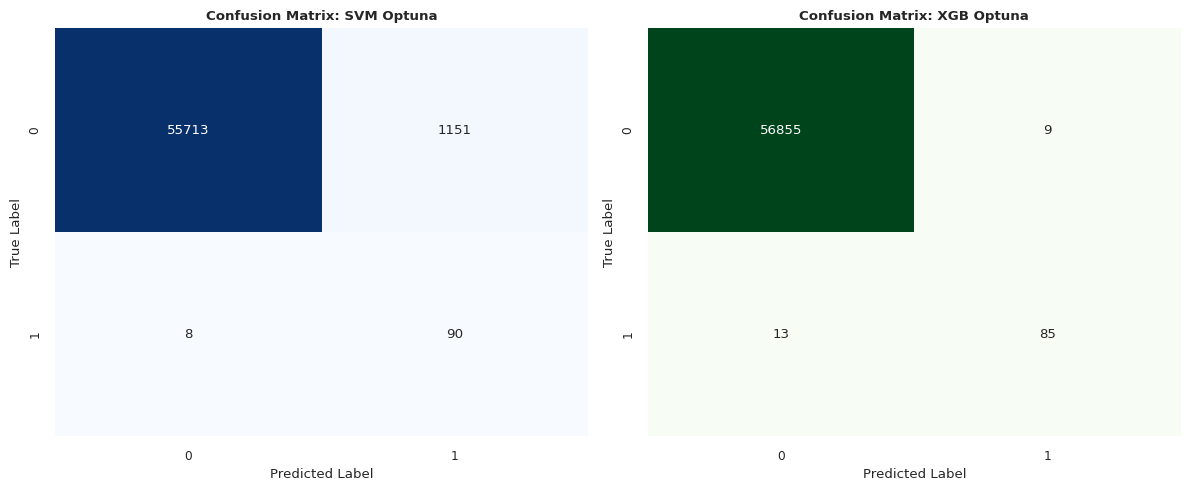

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CM SVM Optuna
cm_svm = confusion_matrix(y_test, y_pred_svm_opt)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix: SVM Optuna', fontweight='bold')

# CM XGB Optuna
cm_xgb = confusion_matrix(y_test, y_pred_xgb_opt)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix: XGB Optuna', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df_comparison = pd.DataFrame({'True Label': y_test.values})
for name, y_pred, _ in models_info:
    df_comparison[name] = y_pred

print("=== Contoh 10 Baris Acak (Campuran Normal & Fraud) ===")
display(df_comparison.sample(10, random_state=42))

print("\n=== Contoh 10 Baris Khusus Transaksi Fraud ===")
display(df_comparison[df_comparison['True Label'] == 1].head(10))

print("\n=== Contoh 10 Baris Khusus Transaksi Normal ===")
display(df_comparison[df_comparison['True Label'] == 0].head(10))

=== Contoh 10 Baris Acak (Campuran Normal & Fraud) ===


,True Label,SVM Under,SVM Over,SVM Cost,SVM Ens,XGB Cost,XGB Under,XGB Over,XGB Ens,SVM Optuna,XGB Optuna
21130,0,0,0,0,0,0,0,0,0,0,0
23642,0,0,0,0,0,0,0,0,0,0,0
462,0,0,0,1,0,0,1,0,1,1,0
19232,0,0,0,0,0,0,0,0,0,0,0
10016,0,0,0,0,0,0,0,0,0,0,0
30838,0,0,0,0,0,0,0,0,0,0,0
22120,0,0,0,1,1,0,0,0,0,1,0
33627,0,0,0,0,0,0,0,0,0,0,0
32751,0,0,0,0,0,0,0,0,0,0,0
44649,0,0,0,0,0,0,0,0,0,0,0



=== Contoh 10 Baris Khusus Transaksi Fraud ===


,True Label,SVM Under,SVM Over,SVM Cost,SVM Ens,XGB Cost,XGB Under,XGB Over,XGB Ens,SVM Optuna,XGB Optuna
840,1,1,1,1,1,1,1,1,1,1,1
1146,1,1,1,1,1,1,1,1,1,1,1
3287,1,1,1,1,1,1,1,1,1,1,1
4276,1,1,1,1,1,1,1,1,1,1,1
5077,1,1,1,1,1,1,1,1,1,1,1
5453,1,1,1,1,1,1,1,1,1,1,1
7164,1,1,1,1,1,1,1,1,1,1,1
7299,1,1,1,1,1,1,1,1,1,1,1
7337,1,1,1,1,1,1,1,1,1,1,1
9036,1,1,1,1,1,1,1,1,1,1,1



=== Contoh 10 Baris Khusus Transaksi Normal ===


,True Label,SVM Under,SVM Over,SVM Cost,SVM Ens,XGB Cost,XGB Under,XGB Over,XGB Ens,SVM Optuna,XGB Optuna
0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0
4,0,1,1,1,1,0,1,0,1,1,0
5,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0
